### Использование моделей с HuggingFace для классификации текста

In [1]:
import torch
import numpy as np
import torch.nn as nn

In [2]:
from transformers import AutoTokenizer
from transformers import BertModel
from transformers import RobertaModel
from transformers import DistilBertModel

def get_model(model_name):
    checkpoint_names = {
        'bert': 'bert-base-cased',
        'roberta': 'roberta-base',
        'distilbert': 'distilbert-base-cased',
    }
    model_classes = {
        'bert': BertModel,
        'roberta': RobertaModel,
        'distilbert': DistilBertModel,
    }
    return AutoTokenizer.from_pretrained(checkpoint_names[model_name]), model_classes[model_name].from_pretrained(checkpoint_names[model_name])

In [3]:
tokenizer, model = get_model('bert')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
tokenizer

BertTokenizer(name_or_path='bert-base-cased', vocab_size=28996, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [5]:
encoding = tokenizer('Hello!', add_special_tokens = True, return_token_type_ids = False, return_tensors = 'pt')

encoding

{'input_ids': tensor([[ 101, 8667,  106,  102]]), 'attention_mask': tensor([[1, 1, 1, 1]])}

In [6]:
tokenizer.decode(encoding['input_ids'])

['[CLS] Hello! [SEP]']

In [7]:
output = model(**encoding)

output

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[ 0.6283,  0.2166,  0.5605,  ...,  0.0136,  0.6158, -0.1712],
         [ 0.6108, -0.2253,  0.9263,  ..., -0.3028,  0.4500, -0.0714],
         [ 0.8040,  0.1809,  0.7076,  ..., -0.0685,  0.4837, -0.0774],
         [ 1.3290,  0.2360,  0.4567,  ...,  0.1509,  0.9621, -0.4841]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[-0.7105,  0.4876,  0.9999, -0.9947,  0.9599,  0.9521,  0.9767, -0.9946,
         -0.9815, -0.6238,  0.9776,  0.9984, -0.9989, -0.9998,  0.8559, -0.9755,
          0.9895, -0.5281, -1.0000, -0.7414, -0.7056, -0.9999,  0.2901,  0.9786,
          0.9729,  0.0734,  0.9828,  1.0000,  0.8981, -0.1109,  0.2780, -0.9920,
          0.8693, -0.9985,  0.1461,  0.2067,  0.8092, -0.2430,  0.8580, -0.9585,
         -0.8130, -0.6138,  0.7961, -0.5727,  0.9737,  0.2362, -0.1194, -0.0789,
          0.0031,  0.9997, -0.9519,  0.9899, -0.9962,  0.9931,  0.9950,  0.5050,
          0.9952,  0.1090,

In [8]:
output.last_hidden_state.shape

torch.Size([1, 4, 768])

In [9]:
output.pooler_output.shape

torch.Size([1, 768])

In [10]:
tokenizer, model = get_model('roberta')

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
encoding = tokenizer('Hello!', add_special_tokens = True, return_token_type_ids = False, return_tensors = 'pt')

encoding

{'input_ids': tensor([[    0, 31414,   328,     2]]), 'attention_mask': tensor([[1, 1, 1, 1]])}

In [12]:
tokenizer

RobertaTokenizer(name_or_path='roberta-base', vocab_size=50265, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50264: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=True, special=True),
}
)

In [13]:
tokenizer.decode(encoding['input_ids'])

['<s>Hello!</s>']

In [14]:
output = model(**encoding)

output

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[-0.0632,  0.0918, -0.0026,  ..., -0.0642, -0.0555,  0.0080],
         [-0.2026, -0.0124,  0.0174,  ..., -0.0176,  0.0094,  0.0870],
         [-0.1557, -0.1340,  0.2350,  ..., -0.0798, -0.1061,  0.5419],
         [-0.0534,  0.0986, -0.0293,  ..., -0.1175, -0.0659, -0.0090]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[ 6.2522e-01, -1.3945e-01,  2.6745e-01,  3.6161e-01,  4.0816e-02,
         -1.8873e-01,  1.2216e-01,  3.7918e-02,  2.8494e-02, -1.7366e-04,
          1.1563e-01,  6.2665e-02,  1.9995e-01,  9.0463e-02,  1.3610e-01,
          1.7200e-01,  5.9310e-02,  9.1971e-02, -9.4848e-02,  2.1527e-01,
         -4.9925e-02, -3.3551e-01,  1.4027e-01, -3.9058e-01,  1.0149e-01,
         -4.4549e-01,  1.4670e-01, -1.2759e-01,  2.2644e-01, -1.5867e-01,
         -2.4692e-01,  1.1592e-01, -1.4008e-01, -2.6655e-01,  3.5963e-01,
         -4.9571e-02,  2.6292e-01,  4.5502e-02,  2.7418e-01, -9.7138e-02,
 

In [15]:
output.last_hidden_state.shape

torch.Size([1, 4, 768])

In [16]:
output.pooler_output.shape

torch.Size([1, 768])

In [17]:
tokenizer, model = get_model('distilbert')

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
tokenizer

BertTokenizer(name_or_path='distilbert-base-cased', vocab_size=28996, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [19]:
encoding = tokenizer('Hello!', add_special_tokens = True, return_token_type_ids = False, return_tensors = 'pt')

encoding

{'input_ids': tensor([[ 101, 8667,  106,  102]]), 'attention_mask': tensor([[1, 1, 1, 1]])}

In [20]:
tokenizer.decode(encoding['input_ids'])

['[CLS] Hello! [SEP]']

In [21]:
output = model(**encoding)

output

BaseModelOutput(last_hidden_state=tensor([[[ 0.3344,  0.2363,  0.1612,  ...,  0.1000,  0.2444, -0.0667],
         [ 0.1081,  0.3777,  0.4785,  ...,  0.3207,  0.6012,  0.1848],
         [ 0.6096,  0.5275,  0.6734,  ...,  0.3253,  0.1565,  0.1588],
         [ 0.5685,  0.6846,  0.5774,  ...,  0.8333,  0.9534, -0.0596]]],
       grad_fn=<NativeLayerNormBackward0>), hidden_states=None, attentions=None)

In [22]:
output.last_hidden_state.shape

torch.Size([1, 4, 768])

### Дообучение BERT для конкретной задачи

### Датасет

In [23]:
from datasets import load_dataset

dataset = load_dataset('imdb')

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [24]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [25]:
dataset['train']

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [26]:
dataset['train'][14]

{'text': 'Today I found "They All Laughed" on VHS on sale in a rental. It was a really old and very used VHS, I had no information about this movie, but I liked the references listed on its cover: the names of Peter Bogdanovich, Audrey Hepburn, John Ritter and specially Dorothy Stratten attracted me, the price was very low and I decided to risk and buy it. I searched IMDb, and the User Rating of 6.0 was an excellent reference. I looked in "Mick Martin & Marsha Porter Video & DVD Guide 2003" and \x96 wow \x96 four stars! So, I decided that I could not waste more time and immediately see it. Indeed, I have just finished watching "They All Laughed" and I found it a very boring overrated movie. The characters are badly developed, and I spent lots of minutes to understand their roles in the story. The plot is supposed to be funny (private eyes who fall in love for the women they are chasing), but I have not laughed along the whole story. The coincidences, in a huge city like New York, are r

In [27]:
def tokenization(example):
    # truncation - ограничивает максимальную длину последовательности
    return tokenizer(example['text'], add_special_tokens = True, return_token_type_ids = False, truncation = True)

train_dataset = dataset['train'].map(tokenization, batched = True)
test_dataset = dataset['test'].map(tokenization, batched = True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [28]:
train_dataset[0].keys()

dict_keys(['text', 'label', 'input_ids', 'attention_mask'])

In [29]:
train_dataset.set_format(type = 'torch', columns = ['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type = 'torch', columns = ['input_ids', 'attention_mask', 'label'])

In [30]:
train_dataset[0]

{'label': tensor(0),
 'input_ids': tensor([  101,   146, 12765,   146,  6586,   140, 19556, 19368, 13329,   118,
           162, 21678,  2162, 17056,  1121,  1139,  1888,  2984,  1272,  1104,
          1155,  1103,  6392,  1115,  4405,  1122,  1165,  1122,  1108,  1148,
          1308,  1107,  2573,   119,   146,  1145,  1767,  1115,  1120,  1148,
          1122,  1108,  7842,  1118,   158,   119,   156,   119, 10148,  1191,
          1122,  1518,  1793,  1106,  3873,  1142,  1583,   117,  3335,  1217,
           170,  5442,  1104,  2441,  1737,   107,  6241,   107,   146,  1541,
          1125,  1106,  1267,  1142,  1111,  1991,   119,   133,  9304,   120,
           135,   133,  9304,   120,   135,  1109,  4928,  1110,  8663,  1213,
           170,  1685,  3619,  3362,  2377,  1417, 14960,  1150,  3349,  1106,
          3858,  1917,  1131,  1169,  1164,  1297,   119,  1130,  2440,  1131,
          3349,  1106,  2817,  1123,  2209,  1116,  1106,  1543,  1199,  3271,
          1104,  4

### Сделаем даталоадеры

In [31]:
from transformers import DataCollatorWithPadding

# collate_fn - для одного размера в батче
data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

In [32]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 32, collate_fn = data_collator, pin_memory = True, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, collate_fn = data_collator, pin_memory = True, shuffle = False)

In [33]:
b = next(iter(train_loader))

In [34]:
b

{'input_ids': tensor([[  101,  1188,  2523,  ...,     0,     0,     0],
        [  101, 23750,   112,  ...,     0,     0,     0],
        [  101,  6151, 17501,  ...,     0,     0,     0],
        ...,
        [  101,   146,  2542,  ...,  1243,  1147,   102],
        [  101,   146,   112,  ...,     0,     0,     0],
        [  101,   146,  4927,  ...,     0,     0,     0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
        0, 1, 0, 1, 0, 0, 0, 1])}

In [35]:
from transformers import AutoTokenizer
from transformers import BertForSequenceClassification
from transformers import RobertaForSequenceClassification
from transformers import DistilBertForSequenceClassification

def get_model_sc(model_name):
    checkpoint_names = {
        'bert': 'bert-base-cased',
        'roberta': 'roberta-base',
        'distilbert': 'distilbert-base-cased',
    }

    model_classes = {
        'bert': BertForSequenceClassification,
        'roberta': RobertaForSequenceClassification,
        'distilbert': DistilBertForSequenceClassification
    }

    return AutoTokenizer.from_pretrained(checkpoint_names[model_name]), model_classes[model_name].from_pretrained(checkpoint_names[model_name])

In [36]:
tokenizer, model = get_model_sc('distilbert')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [37]:
model(**b)

SequenceClassifierOutput(loss=tensor(0.7429, grad_fn=<NllLossBackward0>), logits=tensor([[-0.0142,  0.3337],
        [-0.0340,  0.3125],
        [-0.0186,  0.3029],
        [-0.0508,  0.3439],
        [-0.0187,  0.3220],
        [-0.0133,  0.3294],
        [-0.0412,  0.3383],
        [-0.0336,  0.3391],
        [-0.0373,  0.3113],
        [-0.0535,  0.3372],
        [-0.0060,  0.3092],
        [-0.0164,  0.3169],
        [ 0.0009,  0.3117],
        [-0.0264,  0.3309],
        [-0.0163,  0.3207],
        [-0.0400,  0.3328],
        [-0.0149,  0.3383],
        [-0.0038,  0.3354],
        [-0.0336,  0.3131],
        [-0.0335,  0.3314],
        [-0.0368,  0.3405],
        [-0.0316,  0.3086],
        [-0.0342,  0.3078],
        [-0.0521,  0.3233],
        [-0.0407,  0.3155],
        [-0.0078,  0.3160],
        [-0.0332,  0.3006],
        [-0.0473,  0.3299],
        [ 0.0063,  0.3127],
        [-0.0439,  0.3318],
        [ 0.0089,  0.3099],
        [-0.0165,  0.3106]], grad_fn=<AddmmBackward

### Обучение

In [38]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [39]:
import evaluate

metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis = -1)
    return metric.compute(predictions = predictions, references = labels)

In [40]:
# аргументы для обучения
from transformers import TrainingArguments
# обертка для обучения
from transformers import Trainer

training_args = TrainingArguments(
    output_dir = './results',
    learning_rate = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 5,
    weight_decay = 0.01,
    eval_strategy = 'epoch'
)

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
    #tokenizer = tokenizer,
    data_collator = data_collator,
    compute_metrics = compute_metrics
)

# trainer.train()

### Альтернативный вариант
Сделаем эмбеддинги для объектов датасеты и обучим модель

In [41]:
tokenizer, model = get_model('distilbert')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [43]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [44]:
model = model.to(device)

In [45]:
def tokenization(example):
    return tokenizer(example['text'], add_special_tokens = True, return_token_type_ids = False, truncation = True)

train_dataset = dataset['train'].map(tokenization, batched = True)
test_dataset = dataset['test'].map(tokenization, batched = True)

train_dataset.set_format(type = 'torch', columns = ['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type = 'torch', columns = ['input_ids', 'attention_mask', 'label'])

train_loader = DataLoader(train_dataset, batch_size = 64, collate_fn = data_collator, pin_memory = True, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, collate_fn = data_collator, pin_memory = True, shuffle = False)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [46]:
from tqdm import tqdm

# по всем батчам сохраняем все эмбеддинги и лейблы
@torch.inference_mode()
def get_embedding_labels(model, loader):
    model.eval()

    total_embeddings = []
    labels = []

    for batch in tqdm(loader):
        labels.append(batch['labels'].unsqueeze(1))

        batch = {key: batch[key].to(device) for key in ['attention_mask', 'input_ids']}

        # берем значение для начала строки и сохраняем эмбеддинги
        embeddings = model(**batch)['last_hidden_state'][:, 0, :]
        total_embeddings.append(embeddings.cpu())

    return torch.cat(total_embeddings, dim = 0), torch.cat(labels, dim = 0).to(torch.float32)

In [47]:
train_embeddings, train_labels = get_embedding_labels(model, train_loader)

100%|██████████| 391/391 [06:09<00:00,  1.06it/s]


In [48]:
test_embeddings, test_labels = get_embedding_labels(model, train_loader)

100%|██████████| 391/391 [06:17<00:00,  1.04it/s]


In [49]:
train_embeddings.shape, train_labels.shape

(torch.Size([25000, 768]), torch.Size([25000, 1]))

In [50]:
test_embeddings.shape, test_labels.shape

(torch.Size([25000, 768]), torch.Size([25000, 1]))

In [51]:
from torch.utils.data import TensorDataset
from torch.utils.data import random_split

dataset = TensorDataset(torch.cat([train_embeddings, test_embeddings], dim = 0), torch.cat([train_labels, test_labels], dim = 0))

train_dataset, test_dataset = random_split(dataset, (int(len(dataset) * 0.9), len(dataset) - int(len(dataset) * 0.9)))

train_loader = DataLoader(train_dataset, batch_size = 128, pin_memory = True, shuffle = True)
valid_loader = DataLoader(test_dataset, batch_size = 128, pin_memory = True, shuffle = False)

In [52]:
little_model = nn.Sequential(
    nn.Linear(768, 768),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(768, 1)
)

In [69]:
def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

def train(model):
    model.train()
    
    total_loss = 0
    total_accuracy = 0
    for x, y in tqdm(train_loader, desc = 'Train'):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)

        loss = loss_fn(output, y)
        total_loss += loss.item()
        total_accuracy += binary_accuracy(output, y).cpu()
        
        loss.backward()
        optimizer.step()
    total_loss /= len(train_loader)
    total_accuracy /= len(train_loader)
    return total_loss, total_accuracy

In [70]:
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    
    total_loss = 0
    total_accuracy = 0
    for x, y in tqdm(loader, desc = 'Train'):
        x, y = x.to(device), y.to(device)
        output = model(x)

        loss = loss_fn(output, y)
        total_loss += loss.item()
        total_accuracy += binary_accuracy(output, y).cpu()
        
        
    total_loss /= len(loader)
    total_accuracy /= len(loader)
    return total_loss, total_accuracy

In [71]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
def plot_stats(
    train_loss,
    train_accuracy,
    valid_loss,
    valid_accuracy,
    title: str
):
    plt.figure(figsize = (16, 10))
    plt.title(title)
    plt.plot(train_loss, label = 'Train loss')
    plt.plot(valid_loss, label = 'Test loss')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize = (16, 10))
    plt.title(title)
    plt.plot(train_accuracy, label = 'Train accuracy')
    plt.plot(valid_accuracy, label = 'Test accuracy')
    plt.legend()
    plt.grid()
    plt.show()
    

In [72]:
def whole_train_value_cycle(
    model,
    num_epochs,
    title
):
    train_loss_history = []
    valid_loss_history = []
    train_accuracy_history = []
    valid_accuracy_history = []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model)
        valid_loss, valid_accuracy = evaluate(model, valid_loader)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)
        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history,
            train_accuracy_history,
            valid_loss_history,
            valid_accuracy_history,
            title
        )

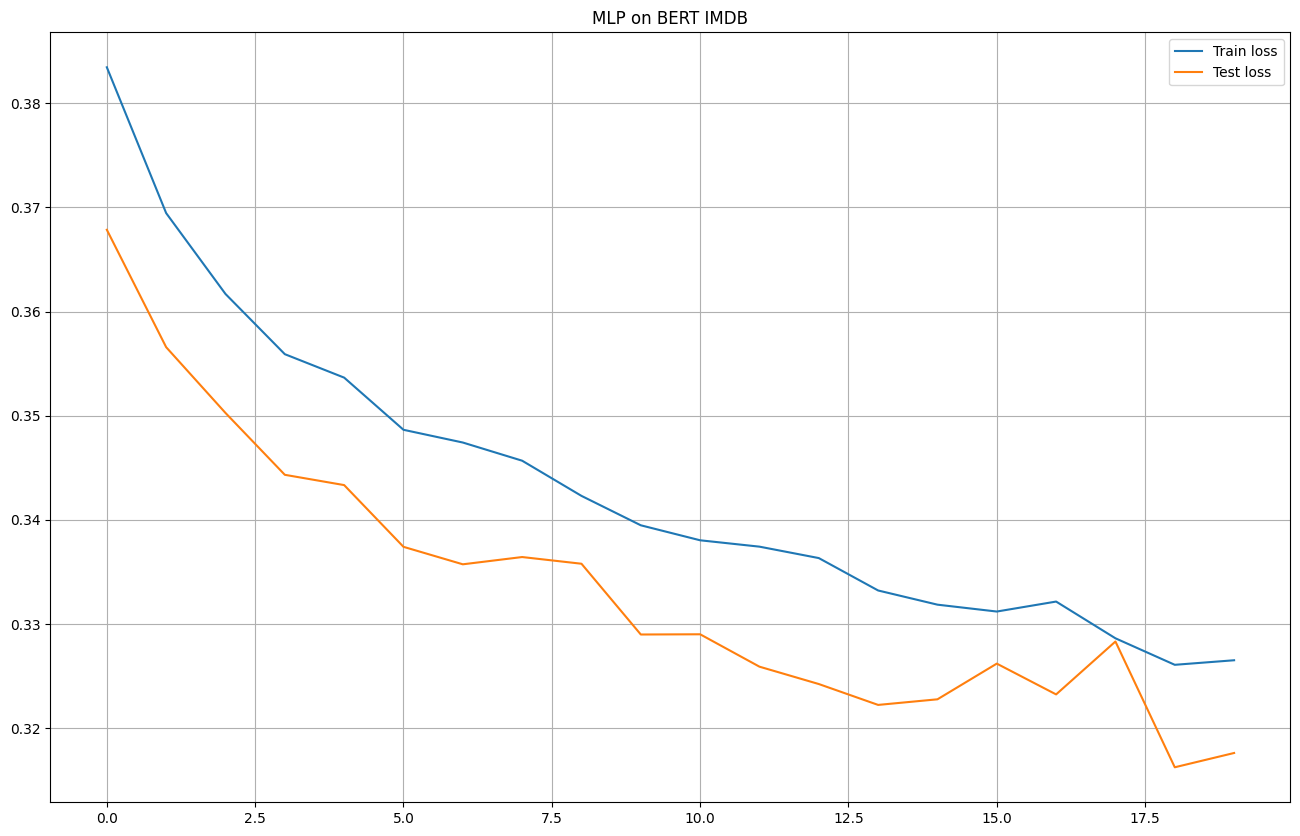

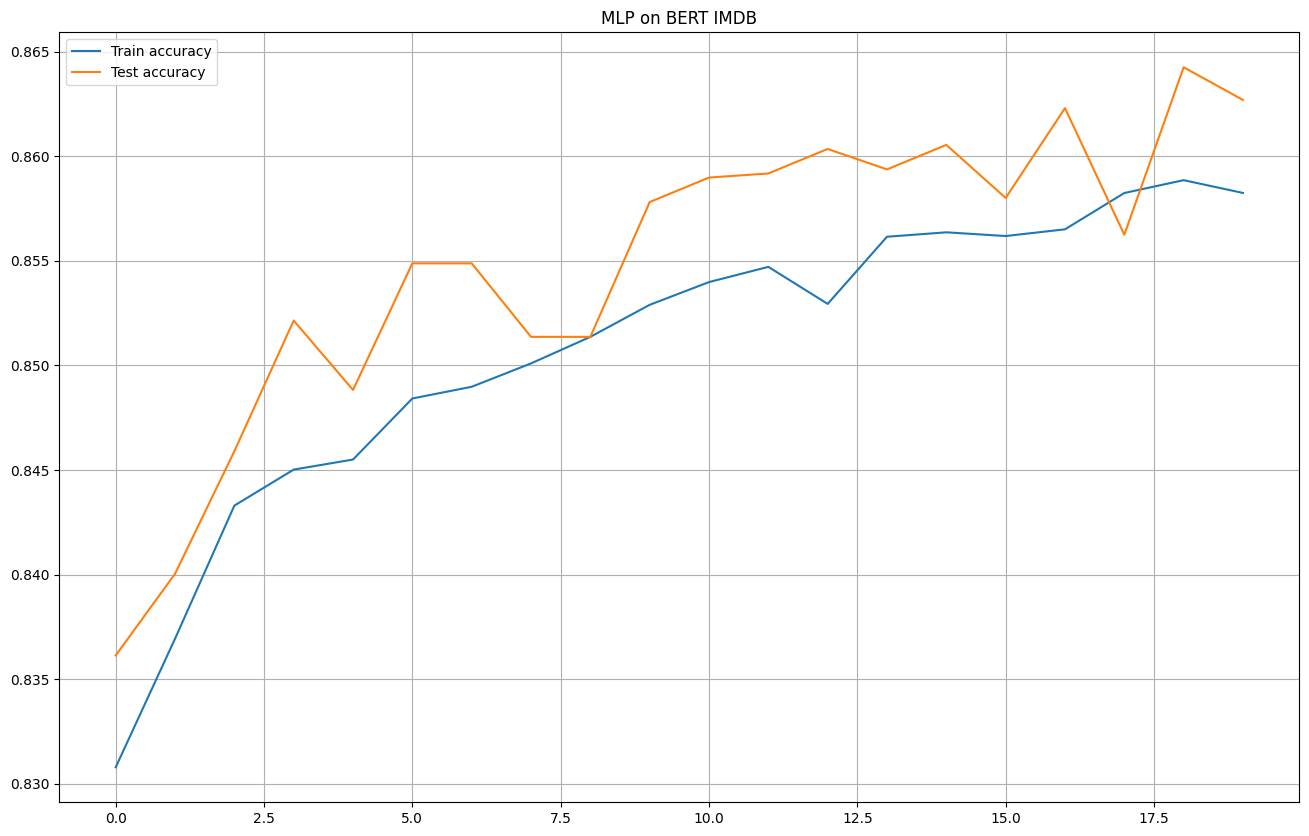

In [73]:
from torch.optim import Adam

little_model = little_model.to(device)
optimizer = Adam(little_model.parameters(), lr = 1e-4)
loss_fn = nn.BCEWithLogitsLoss()

whole_train_value_cycle(little_model, 20, 'MLP on BERT IMDB')

In [ ]:
train_dataset[0]